# P1 · Reshape without losing meaning

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python and PyTorch. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.set_num_threads(1)
torch.manual_seed(7)
print("Python", sys.version.split()[0], "· PyTorch", torch.__version__, "· CPU")
print("Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.")


Python 3.12.3 · PyTorch 2.10.0+cpu · CPU
Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P1.5 · Reshape without losing meaning

Reshape changes grouping; transpose and permute change axis order. A view can share storage with its source.

**Prerequisites:** Assemble sequences and batches

**Predict:** Are reshape(3,2) and transpose of [2,3] generally equal?

**Mental model:** Attention splits features into heads and later joins the heads again. A shape change is correct only if each value keeps the intended coordinate meaning.

### Why this operation exists

Attention splits features into heads and later joins the heads again. A shape change is correct only if each value keeps the intended coordinate meaning.

Reshape reads the values in their logical order and groups them into a new shape. Transpose instead exchanges the meaning of two axes.

Both operations can produce a three-by-two result from the same two-by-three input. Matching shapes therefore cannot prove that the transformations are equivalent.

Views can share storage. Strides describe how an index advances through that storage, and a requested view must be compatible with the existing layout.

Follow numbered values through the transformation. This is more informative than memorizing a sequence of reshape calls.

### Follow the values

The first matrix contains zero, one, two across its first line and three, four, five across its second.

Reshape groups the logical sequence into pairs: zero with one, two with three, and four with five.

Transpose exchanges the axes. Its first pair is zero with three, then one with four, then two with five. The same shape now contains a different arrangement.

Inspect strides: the original advances by three and one; its transpose advances by one and three. The transpose shares storage and is not contiguous in this layout.

Make a contiguous tensor in the transposed order, then flatten it with view. The sequence is zero, three, one, four, two, five. Adding ten changes values without changing these relationships.

In [3]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
x = torch.arange(6).reshape(2, 3) + (10 if change else 0)
show("Original [2,3]", x)
show("Reshape [3,2]", x.reshape(3, 2))
y = x.transpose(0, 1)
show("Transpose [3,2]", y)
show("Layout", {"x stride": list(x.stride()), "y stride": list(y.stride()), "y contiguous": y.is_contiguous()})
packed = y.contiguous().view(-1)
show("Pack transposed order", packed)
assert not torch.equal(x.reshape(3, 2), y)

Original [2,3]: [[0, 1, 2], [3, 4, 5]]
  shape [2, 3] · torch.int64 · cpu
Reshape [3,2]: [[0, 1], [2, 3], [4, 5]]
  shape [3, 2] · torch.int64 · cpu
Transpose [3,2]: [[0, 3], [1, 4], [2, 5]]
  shape [3, 2] · torch.int64 · cpu
Layout: {"x stride": [3, 1], "y stride": [1, 3], "y contiguous": false}
Pack transposed order: [0, 3, 1, 4, 2, 5]
  shape [6] · torch.int64 · cpu


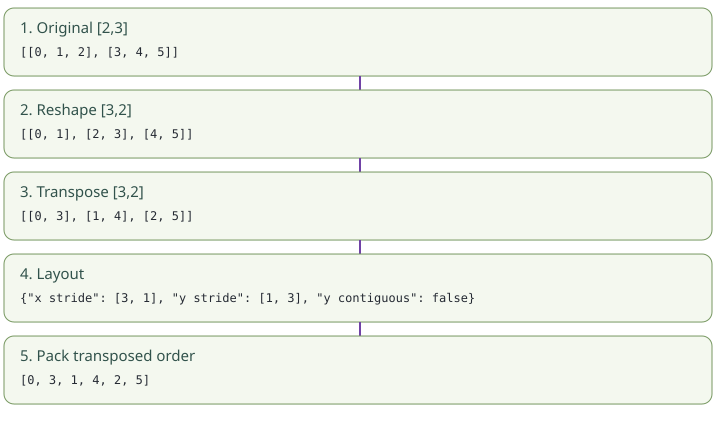

In [4]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

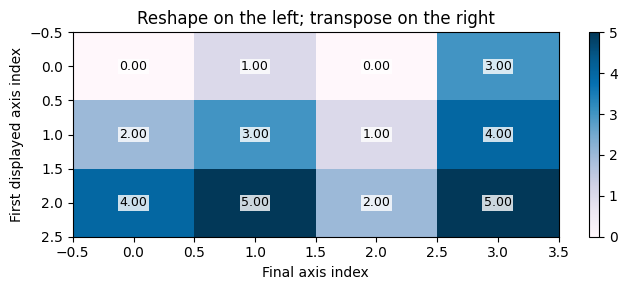

In [5]:
image = (torch.cat([x.reshape(3,2), x.T], dim=1).float()).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Reshape on the left; transpose on the right'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### Read the implementation

Use reshape when the requested shape preserves the number of elements. A single minus one lets the library infer one axis from the others.

Use transpose to exchange two axes and permute to specify an entire axis order. Neither operation means calculate a new learned transformation.

View requires a compatible size and stride layout. Reshape can return a view or make a copy, so do not depend on it always sharing storage.

Contiguous preserves logical values while providing contiguous storage when a copy is needed. Clone explicitly makes independent storage, while detach addresses gradient recording.

Unsqueeze inserts a length-one axis. Squeeze with a specified axis avoids accidentally removing a batch axis when the batch size happens to be one.

### Change one thing

**Add ten to every source value**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [6]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
x = torch.arange(6).reshape(2, 3) + (10 if change else 0)
show("Original [2,3]", x)
show("Reshape [3,2]", x.reshape(3, 2))
y = x.transpose(0, 1)
show("Transpose [3,2]", y)
show("Layout", {"x stride": list(x.stride()), "y stride": list(y.stride()), "y contiguous": y.is_contiguous()})
packed = y.contiguous().view(-1)
show("Pack transposed order", packed)
assert not torch.equal(x.reshape(3, 2), y)

Original [2,3]: [[10, 11, 12], [13, 14, 15]]
  shape [2, 3] · torch.int64 · cpu
Reshape [3,2]: [[10, 11], [12, 13], [14, 15]]
  shape [3, 2] · torch.int64 · cpu
Transpose [3,2]: [[10, 13], [11, 14], [12, 15]]
  shape [3, 2] · torch.int64 · cpu
Layout: {"x stride": [3, 1], "y stride": [1, 3], "y contiguous": false}
Pack transposed order: [10, 13, 11, 14, 12, 15]
  shape [6] · torch.int64 · cpu


### A useful distinction

Equal shapes and equal element counts do not prove equal layouts. reshape is not a substitute for permute.

In [7]:
x = torch.arange(6).reshape(2,3)
y = x.T
try:
    y.view(-1)
except RuntimeError:
    print("This flattened view is incompatible with the transposed strides.")
alias = x.view(-1); alias[0] = 99
assert x[0,0].item() == 99
copied = x.clone(); copied[0,0] = -1
assert x[0,0].item() == 99
assert torch.zeros(1,2,1).squeeze(-1).shape == (1,2)

This flattened view is incompatible with the transposed strides.


### ✋ Your turn

Transpose torch.arange(6).reshape(2,3), then flatten in transposed order; put the list in answer.

In [8]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [0,3,1,4,2,5], 'Equal shapes and equal element counts do not prove equal layouts. reshape is not a substitute for permute.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [9]:
#@title Show a solution { display-mode: "form" }
answer = torch.arange(6).reshape(2,3).T.contiguous().view(-1).tolist()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [0,3,1,4,2,5], 'Equal shapes and equal element counts do not prove equal layouts. reshape is not a substitute for permute.'
    print("✓ right:", answer)

✓ right: [0, 3, 1, 4, 2, 5]


### Reconnect to the transformer

Queries begin with shape batch by time by features. The model groups features into heads, then transposes time and heads to obtain the attention layout.

After the weighted value mixture, it reverses that organization. The transpose is followed by contiguous and view to merge heads into a feature vector per token.

Phyll starts with a fused query-key-value projection and introduces a fifth axis before permuting it. Every step must preserve which values belong to which projection and head.

An incorrect reshape can run without an exception while mixing those meanings. Verify both the output shape and a few original coordinates.

Next, learn when PyTorch can expand a smaller shape across a larger one without changing those axis meanings.

```python
q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
y = (att @ v).transpose(1, 2).contiguous().view(B, T, C)
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Are reshape(3,2) and transpose of [2,3] generally equal?

<details><summary>Check your explanation</summary>

No; grouping and axis exchange differ. Equal shapes and equal element counts do not prove equal layouts. reshape is not a substitute for permute.

</details>